# Parte 2: Ranking e Algoritmo de Score
Neste notebook, combinaremos a análise estatística utilizando o Wilson Lower Bound e o decaimento temporal para definir uma métrica única que determine a utilidade de cada número de telefone da base de cidadãos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys
sys.path.append("../src")
from scoring import calcular_score_telefone, wilson_lower_bound, selecionar_top_n

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../outputs")

# Recarregando dados
df_disparos  = pd.read_parquet(DATA_DIR / "base_disparo_mascarado.parquet", columns=['id_disparo', 'contato_telefone', 'status_disparo'])
df_telefones = pd.read_parquet(DATA_DIR / "dim_telefone_mascarado.parquet")

## 1. Confiabilidade dos Sistemas (Wilson Lower Bound)
Como observado na EDA, a taxa bruta de sucesso sofre viés caso o sistema tenha um volume de amostras muito inferior ou estratosférico em comparação ao resto. O limite inferior de Wilson nos dá uma margem conservadora baseada num nível de confiança.

In [2]:
# Reproduzir o passo da EDA para extrair os sistemas
df_telefones_exploded = df_telefones.explode("telefone_aparicoes").reset_index(drop=True)
df_sistemas = pd.json_normalize(df_telefones_exploded["telefone_aparicoes"])
df_tels_sistemas = pd.concat([df_telefones_exploded.drop(columns=["telefone_aparicoes"]), df_sistemas], axis=1)

# Preparando chaves
df_disparos_slim = df_disparos.dropna(subset=['contato_telefone'])
df_tels_slim = df_tels_sistemas[['telefone_numero', 'id_sistema', 'registro_data_atualizacao', 'cpf', 'telefone_ddd']].dropna(subset=['id_sistema', 'telefone_numero'])

# Merge
df_merged = df_disparos_slim.merge(
    df_tels_slim, 
    left_on="contato_telefone", 
    right_on="telefone_numero", 
    how="inner"
)
df_merged['is_delivered'] = df_merged['status_disparo'] == 'delivered'

# Calculando Taxa
performance = df_merged.groupby('id_sistema').agg(
    total_disparos=('id_disparo', 'count'),
    sucessos=('is_delivered', 'sum')
).reset_index()

# Aplicando Wilson Lower Bound (Confiança de 95%)
performance['wilson_score'] = performance.apply(
    lambda r: wilson_lower_bound(r['sucessos'], r['total_disparos'], 0.95), axis=1
)

# Ranking
performance = performance.sort_values('wilson_score', ascending=False)
sistema_scores = dict(zip(performance['id_sistema'], performance['wilson_score']))

print("Top 10 Sistemas por Wilson Lower Bound Score:")
performance.head(10)

Top 10 Sistemas por Wilson Lower Bound Score:


,id_sistema,total_disparos,sucessos,wilson_score
3,1257277410380486863,1550353,618138,0.397937
0,-133612832286195827,3791783,1491897,0.392964
5,4458959843028638627,53053,18328,0.341431
1,-2757366171786647144,10908,3568,0.318357
4,3094574413675758272,690985,170746,0.246090
2,-4704067261970591609,197224,42372,0.213035


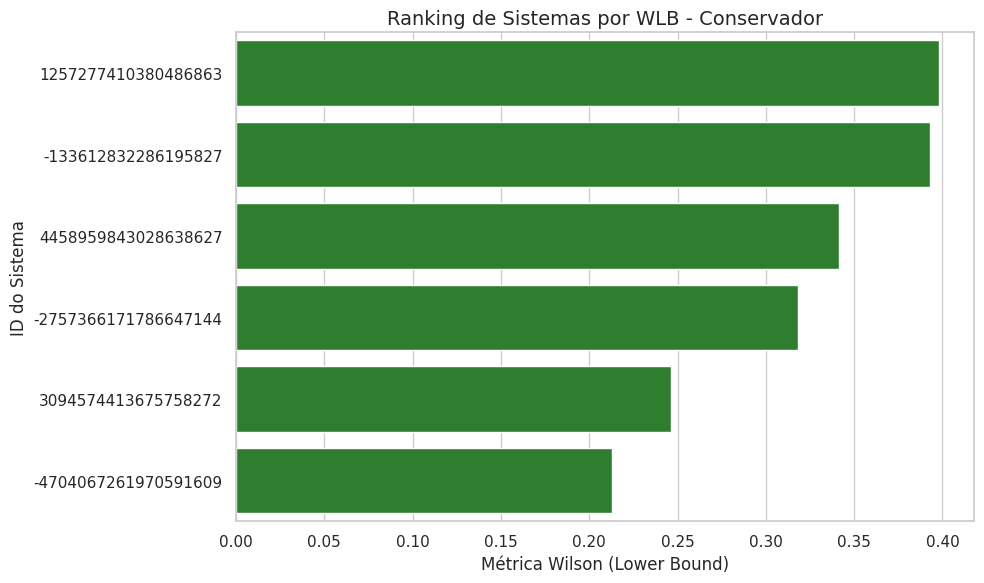

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=performance.head(15), x='wilson_score', y='id_sistema', color='forestgreen')
plt.title("Ranking de Sistemas por WLB - Conservador", fontsize=14)
plt.xlabel("Métrica Wilson (Lower Bound)")
plt.ylabel("ID do Sistema")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wilson_ranking_sistemas.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Aplicando a Inteligência de Escolha (Score Unificado)
Temos que combinar o sistema (`wilson_score`), o decaimento (`registro_data_atualizacao`) e a preferência de região (DDD = 21).

In [4]:
# Simulação! Vamos pegar uma amostra de 1000 CPFs para testar o algoritmo de motor de busca
# Em ambiente produtivo isso roda via pyspark ou pandas no batch job diario
amostra_cpf = df_tels_slim['cpf'].dropna().drop_duplicates().sample(1000, random_state=42)
df_simulacao = df_tels_slim[df_tels_slim['cpf'].isin(amostra_cpf)].copy()

print(f"Simulando em {df_simulacao.shape[0]} registros vinculados a 1000 CPFs.")

hoje = pd.Timestamp.now()
df_simulacao['score'] = df_simulacao.apply(
    lambda row: calcular_score_telefone(
        row,
        sistema_scores=sistema_scores,
        hoje=hoje,
        peso_sistema=0.50,
        peso_frescor=0.40,
        peso_ddd=0.10,
        ddd_preferencial="21"
    ), axis=1
)

df_simulacao[['cpf', 'telefone_numero', 'id_sistema', 'registro_data_atualizacao', 'telefone_ddd', 'score']].sort_values('score', ascending=False).head(10)

Simulando em 1276 registros vinculados a 1000 CPFs.


,cpf,telefone_numero,id_sistema,registro_data_atualizacao,telefone_ddd,score
1499000,-4704055496000924442,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
9209,3789763669447853812,6216327494460661487,1257277410380486863,None,-1181433720517268842,0.669
1528890,-4413447164729229099,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
1503811,1977818690548898544,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
1496416,1398119984522414704,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
1496408,-1244595943318490002,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
1492695,-7962054634239167261,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
1491739,5053271125359664600,9053288731222425178,1257277410380486863,None,749005269938798316,0.669
741374,4585756289240595642,-8348751315127725056,1257277410380486863,None,-1181433720517268842,0.669
603934,5376036096424454430,7806417364749406194,1257277410380486863,None,-1181433720517268842,0.669


## 3. Top N Telefones
Se o mesmo CPF tiver dezenas de números (Múltiplas instâncias entre bancos como Saúde vs IPTU), filtraremos os TOP 2 números unificados usando a função `selecionar_top_n`.

In [5]:
df_top_telefones = selecionar_top_n(df_simulacao, id_cidadao_col='cpf', score_col='score', n=2)

print(f"Total de contatos mantidos após filtro Top 2: {df_top_telefones.shape[0]}")

# Validando que ninguem tem mais de 2 telefones
print("Maior quantia de telefones por CPF:", df_top_telefones.groupby('cpf').size().max())

df_top_telefones[['cpf', 'telefone_numero', 'score']].head(10)

Total de contatos mantidos após filtro Top 2: 1197
Maior quantia de telefones por CPF: 2


,cpf,telefone_numero,score
0,-4704055496000924442,9053288731222425178,0.669
1,3789763669447853812,6216327494460661487,0.669
2,-4413447164729229099,9053288731222425178,0.669
3,1977818690548898544,9053288731222425178,0.669
4,1398119984522414704,9053288731222425178,0.669
5,-1244595943318490002,9053288731222425178,0.669
6,-7962054634239167261,9053288731222425178,0.669
7,5053271125359664600,9053288731222425178,0.669
8,4585756289240595642,-8348751315127725056,0.669
9,5376036096424454430,7806417364749406194,0.669
